# If/else upper controller with the real lower heuristic

This notebook runs one active upper-training scenario without PPO. A deterministic if/else controller produces the 3×3 upper bias matrix, while the existing directional lower heuristic, A3 handover logic, safe-admission layer, PRB-demand conservation, and radio simulator remain active.

The notebook plots geometry, initial and final load matrices, bias and offset matrices, handovers, SLA, and QoS.

## 1. Imports and experiment configuration

Change `SCENARIO_NAME` to any name in `upper_agent_training_scenarios.py`. The timing below is coherent: each upper window advances one second of mobility and one second of radio service.

In [1]:
import ast
import json
import os
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/mpl')
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)

import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np
import pandas as pd
from IPython.display import display

from global_ppo_3gnb_env import DEFAULT_GNB_CONFIGS_3, GlobalPPO3GNBEnv, SLICE_TYPES
from upper_agent_training_scenarios import UPPER_TRAINING_SCENARIO_BY_NAME

plt.style.use('seaborn-v0_8-whitegrid')
SCENARIO_NAME = 'fixed_embb_g0_overlap'
SEED = 23
UPPER_WINDOW_SECONDS = 1.0
LOCAL_STEPS = 10
RADIO_SUBSTEPS = 10
RADIO_TICK_SECONDS = 0.01
LOAD_DEADBAND = 0.04
MAX_RELEASE_BIAS = 1.0

scenario = UPPER_TRAINING_SCENARIO_BY_NAME[SCENARIO_NAME]
print(SCENARIO_NAME, '| tier:', scenario.tier, '| duration:', scenario.duration_s, 's')
print(scenario.description)

fixed_embb_g0_overlap | tier: fixed | duration: 16.0 s
Fixed eMBB UEs in the gNB0-gNB1 overlap teach release intensity.


## 2. Scenario geometry

Dots show UE starting positions and arrows show movement over the episode. Fixed targeted UEs stay in the overlap region. This reproduces the placement equation used by the environment.

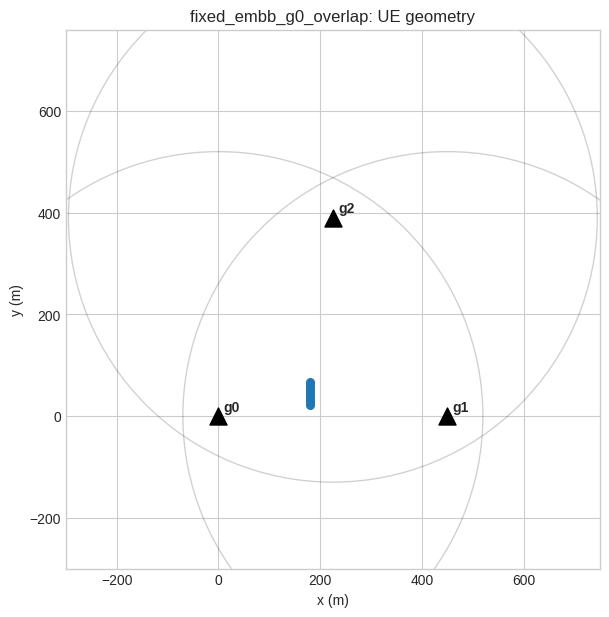

In [2]:
gnbs = {int(g['id']): g for g in DEFAULT_GNB_CONFIGS_3}
slice_colors = {'eMBB': 'tab:blue', 'URLLC': 'tab:red', 'mMTC': 'tab:green'}

def group_points(group, group_idx):
    source = gnbs[group.source_gnb]
    rows = []
    for ue_idx in range(group.count):
        if group.target_gnb is None:
            angle = 2*np.pi*(ue_idx + 1)/max(group.count, 1)
            radius = 35 + 8*group_idx
            start = np.array([source['x'] + radius*np.cos(angle), source['y'] + radius*np.sin(angle)])
            velocity = np.zeros(2)
        else:
            target = gnbs[group.target_gnb]
            delta = np.array([target['x']-source['x'], target['y']-source['y']], dtype=float)
            unit = delta/max(np.linalg.norm(delta), 1e-9)
            perpendicular = np.array([-unit[1], unit[0]])
            lateral = group.lateral_offset_m + (ue_idx - .5*(group.count-1))*5
            start = np.array([source['x'], source['y']]) + group.path_progress*delta + lateral*perpendicular
            velocity = group.speed_mps*unit
        rows.append((start, start + velocity*scenario.duration_s))
    return rows

fig, ax = plt.subplots(figsize=(8, 7))
for g in gnbs.values():
    ax.add_patch(Circle((g['x'], g['y']), g['coverage_radius'], fill=False, alpha=.18))
    ax.scatter(g['x'], g['y'], marker='^', s=150, color='black', zorder=5)
    ax.text(g['x']+10, g['y']+10, f"g{g['id']}", weight='bold')
for group_idx, group in enumerate(scenario.groups):
    color = slice_colors[group.slice_type]
    for start, end in group_points(group, group_idx):
        ax.scatter(*start, color=color, s=30, zorder=4)
        if np.linalg.norm(end-start) > 0:
            ax.annotate('', xy=end, xytext=start,
                        arrowprops=dict(arrowstyle='->', color=color, alpha=.35))
            ax.scatter(*end, marker='x', color=color)
ax.set(xlim=(-300, 750), ylim=(-300, 760), xlabel='x (m)', ylabel='y (m)',
       title=f'{SCENARIO_NAME}: UE geometry')
ax.set_aspect('equal')
plt.show()

## 3. If/else upper controller

For each slice, the controller compares every gNB with that slice's current network mean:

- Above mean + deadband → negative bias, requesting release.
- Below mean − deadband → positive bias, encouraging retention/admission.
- Inside the deadband → zero bias.

The magnitude grows with distance from the mean. This is only the upper decision; the real lower heuristic still chooses directional A3 offsets.

In [3]:
def if_else_upper_action(load_matrix, deadband=LOAD_DEADBAND):
    loads = np.asarray(load_matrix, dtype=float)
    means = loads.mean(axis=0, keepdims=True)
    delta = loads - means
    bias = np.zeros_like(loads)
    overloaded = delta > deadband
    underloaded = delta < -deadband
    scale = max(0.20, 2*deadband)
    bias[overloaded] = -np.minimum(MAX_RELEASE_BIAS, delta[overloaded]/scale)
    bias[underloaded] = np.minimum(MAX_RELEASE_BIAS, -delta[underloaded]/scale)
    return bias.astype(np.float32)

example = np.zeros((3, 3))
for group in scenario.groups:
    example[group.source_gnb, SLICE_TYPES.index(group.slice_type)] += group.total_load
display(pd.DataFrame(example, index=['g0','g1','g2'], columns=SLICE_TYPES))
display(pd.DataFrame(if_else_upper_action(example), index=['g0','g1','g2'], columns=SLICE_TYPES))

,eMBB,URLLC,mMTC
g0,0.86,0.0,0.0
g1,0.00,0.0,0.0
g2,0.00,0.0,0.0


,eMBB,URLLC,mMTC
g0,-1.0,0.0,0.0
g1,1.0,0.0,0.0
g2,1.0,0.0,0.0


## 4. Run the real environment

At each upper window, the controller reads the current load matrix and emits one bias matrix. The environment converts it to directional offsets, applies admission and stability checks, executes handovers, then advances mobility and radio service.

In [4]:
def make_env():
    return GlobalPPO3GNBEnv(
        seed=SEED, scenario_mode='curriculum', training_scenarios=SCENARIO_NAME,
        scenario_selection='cycle', terminal_reward_only=False,
        upper_window_seconds=UPPER_WINDOW_SECONDS,
        local_steps_per_global=LOCAL_STEPS,
        radio_substeps=RADIO_SUBSTEPS,
        radio_tick_seconds=RADIO_TICK_SECONDS,
        max_handovers_per_local_step=1,
        max_handovers_per_ue_episode=2,
        max_handovers_per_episode=20,
        handover_pingpong_guard_s=15,
    )

env = make_env()
obs, info = env.reset(seed=SEED)
initial_load = np.asarray(info['load_matrix'], dtype=float).copy()
records = []
done = False
while not done:
    load_before = np.asarray(info['load_matrix'], dtype=float)
    bias = if_else_upper_action(load_before)
    obs, reward, terminated, truncated, info = env.step(bias.reshape(-1))
    admission = info['safe_admission']['stats']
    records.append({
        'time_s': info['episode_time_s'], 'reward': reward,
        'handovers': info['handover_count'], 'sla_count': info['sla_count'],
        'sla_severity': info['sla_severity'],
        'load_variance': info['load_variance'],
        'delivery_ratio': info['qos']['network_delivery_ratio'],
        'delay_ms': info['qos']['network_completed_delay_ms'],
        'queue_kbits': info['qos']['network_queue_kbits'],
        'load': np.asarray(info['load_matrix'], dtype=float).copy(),
        'bias': bias.copy(),
        'offsets': np.asarray(info['directional_offset_tensor'], dtype=float).copy(),
        'accepted': admission.get('accepted', 0),
        'rejected_target_safety': admission.get('rejected_target_safety', 0),
        'rejected_step_budget': admission.get('rejected_step_budget', 0),
    })
    done = terminated or truncated

final_load = records[-1]['load']
trace = pd.DataFrame([{k:v for k,v in row.items() if k not in {'load','bias','offsets'}} for row in records])
print('Upper windows:', len(records), '| total handovers:', int(trace.handovers.sum()))
display(trace)
env.close()

Upper windows: 16 | total handovers: 19


,time_s,reward,handovers,sla_count,sla_severity,load_variance,delivery_ratio,delay_ms,queue_kbits,accepted,rejected_target_safety,rejected_step_budget
0,1.0,-9.199421,6,2.0,0.656401,0.002756,0.818658,55.835913,267.486333,6,0,45
1,2.0,-0.162123,1,2.0,0.666667,0.000956,0.635794,4.749164,619.037933,1,0,3
2,3.0,0.166133,0,2.0,0.655479,0.000956,0.650960,24.323432,950.589933,0,0,0
3,4.0,-0.167817,0,2.0,0.666667,0.000956,0.649106,4.651163,1283.819933,0,0,0
4,5.0,0.000000,0,2.0,0.666667,0.000956,0.643347,3.624161,1622.602933,0,0,0
5,6.0,-0.005867,2,2.0,0.666667,0.006822,0.959041,1691.471910,1664.072933,2,0,6
6,7.0,0.000743,2,2.0,0.666667,0.002022,0.629733,5.741935,2016.630133,2,0,10
7,8.0,-0.008640,2,2.0,0.666667,0.005756,1.031855,2047.037037,1983.363933,2,0,10
8,9.0,-0.001349,2,2.0,0.666667,0.002756,0.630054,21.961415,2335.592933,2,0,4
9,10.0,-0.005564,0,2.0,0.666667,0.002756,0.630600,4.784053,2675.978933,0,0,0


## 5. Load matrix before and after

These matrices are the normalized used PRBs per gNB and slice. The PRB-demand conservation fix guarantees that UE demand carried across a handover is clipped within the target slice budget.

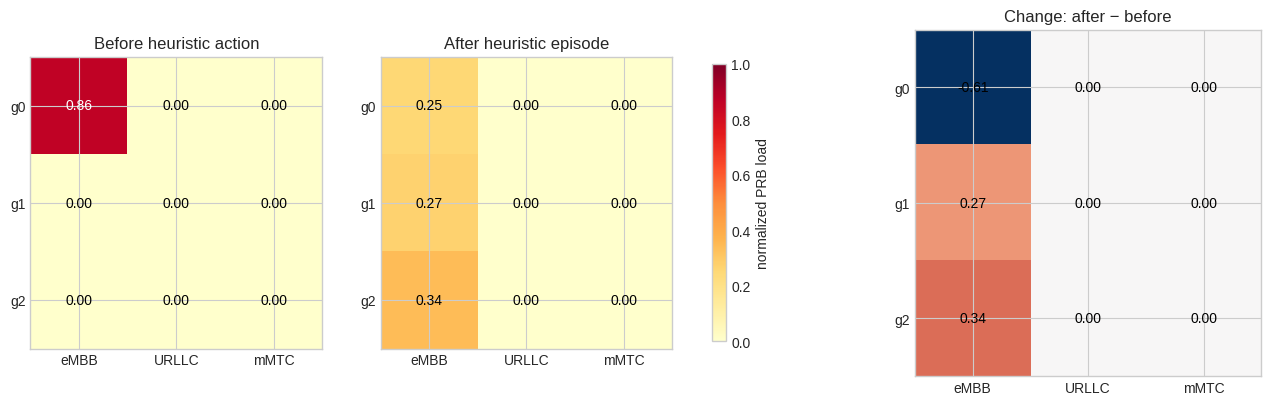

Initial variance: 0.1644
Final variance:   0.0015


In [5]:
def heatmap(ax, matrix, title, cmap='YlOrRd', vmin=0, vmax=1):
    image = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(3), SLICE_TYPES)
    ax.set_yticks(range(3), ['g0','g1','g2'])
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{matrix[i,j]:.2f}', ha='center', va='center',
                    color='white' if matrix[i,j] > .55 else 'black')
    return image

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
im = heatmap(axes[0], initial_load, 'Before heuristic action')
heatmap(axes[1], final_load, 'After heuristic episode')
difference = final_load-initial_load
lim = max(abs(difference).max(), .01)
heatmap(axes[2], difference, 'Change: after − before', cmap='RdBu_r', vmin=-lim, vmax=lim)
fig.colorbar(im, ax=axes[:2], shrink=.8, label='normalized PRB load')
plt.show()

print('Initial variance:', round(sum(np.var(initial_load[:,s]) for s in range(3)), 4))
print('Final variance:  ', round(sum(np.var(final_load[:,s]) for s in range(3)), 4))

## 6. Load evolution, reward, handovers, and QoS

The first plot shows every active gNB/slice load over simulated time. The remaining plots reveal whether lower variance was obtained with reasonable handovers and without damaging delivery or delay.

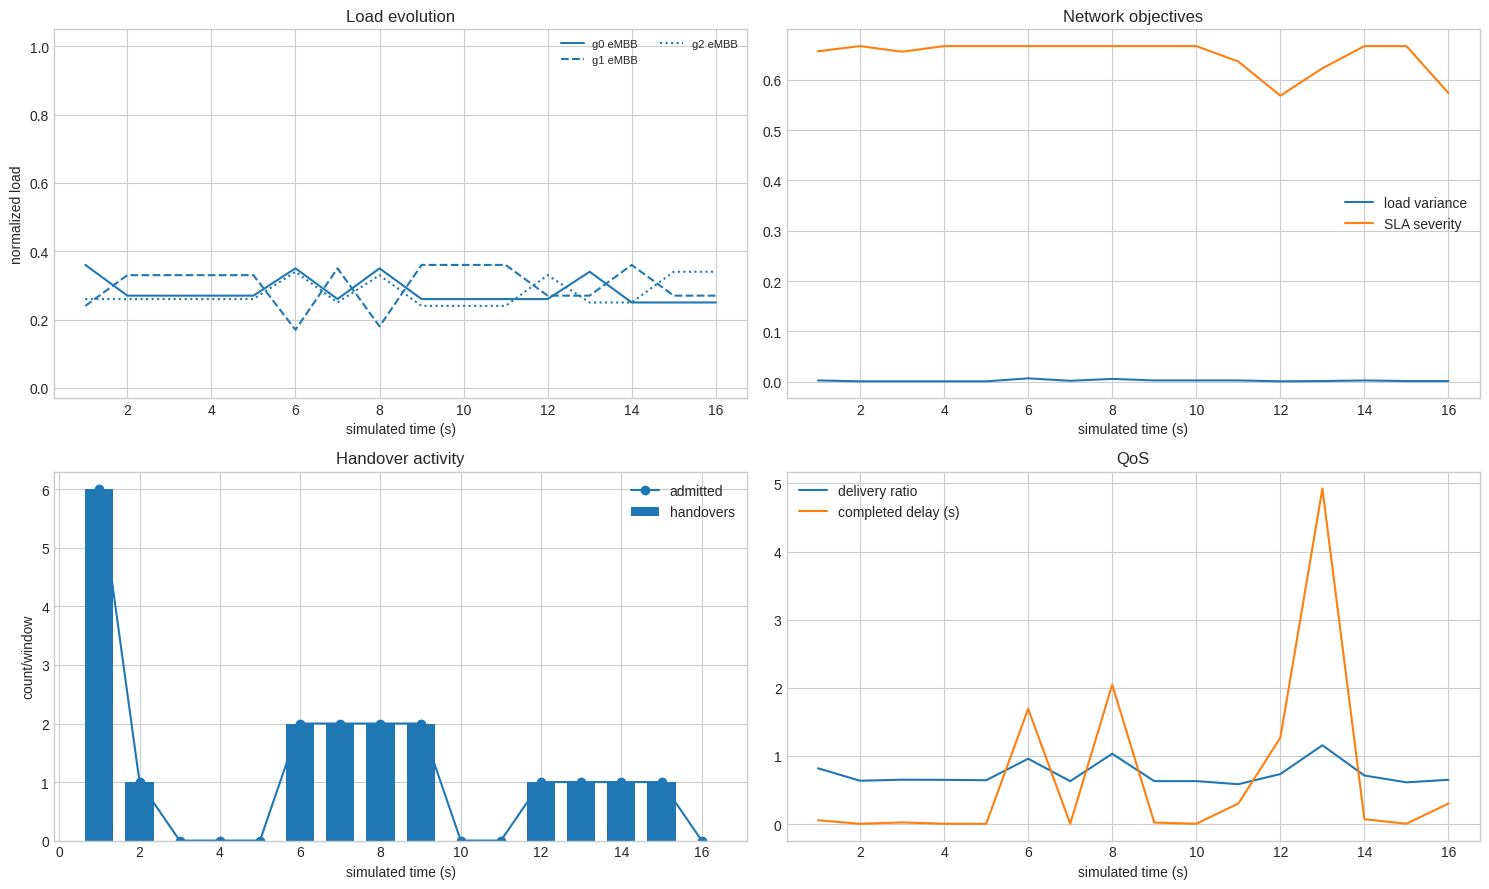

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
times = trace.time_s.to_numpy()
for g in range(3):
    for s, slice_type in enumerate(SLICE_TYPES):
        values = [row['load'][g,s] for row in records]
        if max(values) > 0:
            axes[0,0].plot(times, values, label=f'g{g} {slice_type}', color=slice_colors[slice_type],
                           linestyle=['-','--',':'][g])
axes[0,0].set(title='Load evolution', xlabel='simulated time (s)', ylabel='normalized load', ylim=(-.03,1.05))
axes[0,0].legend(ncol=2, fontsize=8)
axes[0,1].plot(times, trace.load_variance, label='load variance')
axes[0,1].plot(times, trace.sla_severity, label='SLA severity')
axes[0,1].set(title='Network objectives', xlabel='simulated time (s)')
axes[0,1].legend()
axes[1,0].bar(times, trace.handovers, width=.7, label='handovers')
axes[1,0].plot(times, trace.accepted, marker='o', label='admitted')
axes[1,0].set(title='Handover activity', xlabel='simulated time (s)', ylabel='count/window')
axes[1,0].legend()
axes[1,1].plot(times, trace.delivery_ratio, label='delivery ratio')
axes[1,1].plot(times, trace.delay_ms/1000, label='completed delay (s)')
axes[1,1].set(title='QoS', xlabel='simulated time (s)')
axes[1,1].legend()
plt.tight_layout()
plt.show()

## 7. Upper bias and lower directional offsets

Select an upper window below. The middle plot is the if/else upper bias. The right table shows the lower heuristic's two directional offsets for every source gNB and slice.

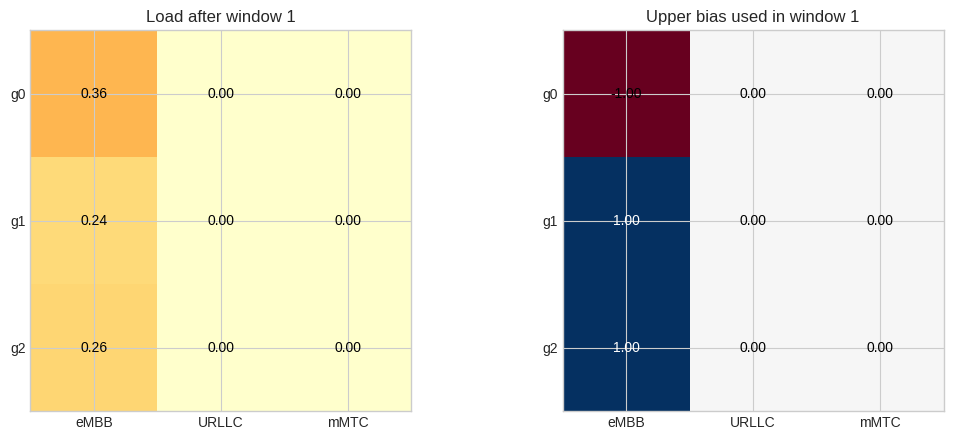

slice          URLLC  eMBB  mMTC
source target                   
g0     g1        0.0 -12.0   0.0
       g2        0.0 -12.0   0.0
g1     g0        0.0   4.0   0.0
       g2        0.0   4.0   0.0
g2     g0        0.0   4.0   0.0
       g1        0.0   4.0   0.0

In [7]:
WINDOW = min(0, len(records)-1)
row = records[WINDOW]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
heatmap(axes[0], row['load'], f'Load after window {WINDOW+1}')
heatmap(axes[1], row['bias'], f'Upper bias used in window {WINDOW+1}', cmap='RdBu', vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

neighbor_graph = {0:[1,2], 1:[0,2], 2:[0,1]}
offset_rows = []
for source in range(3):
    for slot, target in enumerate(neighbor_graph[source]):
        for s, slice_type in enumerate(SLICE_TYPES):
            offset_rows.append({'source':f'g{source}', 'target':f'g{target}', 'slice':slice_type,
                                'offset_db':row['offsets'][source,slot,s]})
display(pd.DataFrame(offset_rows).pivot(index=['source','target'], columns='slice', values='offset_db'))

## 8. Compact result summary

Use this table to decide whether the rule improved balance safely. A good outcome lowers variance without filling targets to 1.0, keeps handovers within budget, and avoids worsening SLA/QoS.

In [8]:
summary = pd.Series({
    'scenario': SCENARIO_NAME,
    'duration_s': scenario.duration_s,
    'initial_load_variance': sum(np.var(initial_load[:,s]) for s in range(3)),
    'final_load_variance': sum(np.var(final_load[:,s]) for s in range(3)),
    'total_reward': trace.reward.sum(),
    'total_handovers': trace.handovers.sum(),
    'max_load_seen': max(float(row['load'].max()) for row in records),
    'final_delivery_ratio': trace.delivery_ratio.iloc[-1],
    'final_delay_ms': trace.delay_ms.iloc[-1],
    'final_sla_severity': trace.sla_severity.iloc[-1],
})
display(summary.to_frame('value'))

,value
scenario,fixed_embb_g0_overlap
duration_s,16.0
initial_load_variance,0.164356
final_load_variance,0.001489
total_reward,-7.987093
total_handovers,19
max_load_seen,0.36
final_delivery_ratio,0.649519
final_delay_ms,301.424332
final_sla_severity,0.573342
